# Urban Demand Forecasting — RQ2 
This standalone notebook implements **Research Question 2 (RQ2)**:

> Which contextual modalities contribute most to forecasting performance under distinct urban demand regimes such as commuting, leisure, weekends, holidays, and adverse-weather conditions?

The notebook auto-fetches the UCI Bike Sharing Dataset if `hour.csv` is not already available. On Kaggle, turn **Internet = On** before running.

## Thesis-ready outputs

This version produces:

- **4 thesis-ready PDF figures** with academic titles, clear labels, and regime-specific interpretation markers.
- **3 CSV tables** with best-model flags, modality gain interpretation, and thesis-safe conclusions.
- A final ZIP file containing all RQ2 outputs.

Important methodology note: UCI Bike Sharing contains real demand, weather, and calendar variables, but it does **not** include real station-level land-use or POI metadata. Therefore, the neighborhood-context variables in this notebook are transparent proxy features. For a final publication-level thesis, replace these with real spatial metadata if available.


In [4]:
RQ = 'RQ2'

# ============================================================
# Common setup: auto-fetch dataset, preprocessing, metrics, models
# ============================================================
import os, glob, zipfile, urllib.request, warnings, shutil, math, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Thesis-ready plotting defaults: larger fonts, clean PDF export, readable axes.
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RQ = globals().get('RQ', 'RQ')
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_DIR / f'urban_demand_{RQ}_outputs'
FIG_DIR = OUTPUT_DIR / 'figures_pdf'
TAB_DIR = OUTPUT_DIR / 'tables_csv'
for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)

def section(title):
    print('\n' + '='*90)
    print(title)
    print('='*90)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path

def save_fig(name):
    path = FIG_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path

def find_or_download_hour_csv():
    candidates = []
    search_roots = ['/kaggle/input', '/kaggle/working', str(Path.cwd()), '/mnt/data']
    for root in search_roots:
        if Path(root).exists():
            candidates.extend(glob.glob(os.path.join(root, '**', 'hour.csv'), recursive=True))
    if candidates:
        print('Found hour.csv:', candidates[0])
        return candidates[0]

    print('hour.csv not found. Downloading UCI Bike Sharing Dataset...')
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    zip_path = OUTPUT_DIR / 'bike_sharing_dataset.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(OUTPUT_DIR / 'uci_bike_sharing')
        found = glob.glob(str(OUTPUT_DIR / 'uci_bike_sharing' / '**' / 'hour.csv'), recursive=True)
        if not found:
            raise FileNotFoundError('Downloaded zip did not contain hour.csv')
        print('Downloaded and extracted:', found[0])
        return found[0]
    except Exception as e:
        raise RuntimeError(
            'Could not fetch hour.csv automatically. On Kaggle, enable Internet in Notebook Settings, '
            'or add a dataset containing UCI Bike Sharing hour.csv. Original error: ' + str(e)
        )

def load_bike_data():
    hour_path = find_or_download_hour_csv()
    df = pd.read_csv(hour_path)
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
    df = df.sort_values('datetime').reset_index(drop=True)
    print('Loaded shape:', df.shape)
    print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
    return df

def build_features(raw):
    df = raw.copy().sort_values('datetime').reset_index(drop=True)
    # Demand regimes aligned with the proposal: commute, leisure, weekend, holiday, severe weather, mixed.
    commute = (df['workingday'].eq(1)) & (df['hr'].isin([7,8,9,16,17,18,19]))
    leisure = (df['hr'].between(10,20)) & ((df['weekday'].isin([0,6])) | (df['holiday'].eq(1)))
    severe = df['weathersit'].ge(3)
    conditions = [severe, df['holiday'].eq(1), commute, leisure, df['weekday'].isin([0,6])]
    labels = ['Severe Weather', 'Holiday', 'Commute', 'Leisure', 'Weekend']
    df['regime'] = np.select(conditions, labels, default='Mixed Regime')

    # Transparent proxy neighborhood semantics because UCI has no station / POI metadata.
    # For a final thesis, replace this block with real station-level POI / land-use metadata.
    df['neighborhood_type'] = np.select(
        [commute & df['hr'].isin([7,8,9]), commute & df['hr'].isin([16,17,18,19]), leisure & df['season'].isin([2,3]), df['hr'].between(10,15) & df['workingday'].eq(1), severe],
        ['CBD', 'Residential', 'Tourist', 'University', 'Transit Hub'],
        default='Mixed-use'
    )
    # Pseudo-stations to enable cross-station and neighborhood experiments on UCI.
    df['station_id'] = (df['neighborhood_type'].astype('category').cat.codes * 10 + (df['hr'] // 4)).astype(int)
    df['station_id'] = 'S' + df['station_id'].astype(str).str.zfill(2)

    # Neighborhood feature proxies created from available temporal/weather indicators.
    nmap = {
        'CBD':          [0.20, 0.85, 0.95, 0.15, 0.25, 0.90],
        'Residential':  [0.90, 0.25, 0.30, 0.20, 0.15, 0.45],
        'University':   [0.35, 0.45, 0.30, 0.95, 0.30, 0.60],
        'Tourist':      [0.25, 0.55, 0.40, 0.25, 0.95, 0.65],
        'Transit Hub':  [0.35, 0.65, 0.55, 0.20, 0.35, 1.00],
        'Mixed-use':    [0.50, 0.55, 0.50, 0.45, 0.45, 0.65]
    }
    cols = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for j,c in enumerate(cols):
        df[c] = df['neighborhood_type'].map(lambda x: nmap[x][j]).astype(float)

    # Time encodings
    df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
    df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)
    df['month'] = df['datetime'].dt.month
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_commute'] = commute.astype(int)
    df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        df[f'lag_{lag}'] = df['cnt'].shift(lag)
    for win in [3,6,24,168]:
        df[f'roll_mean_{win}'] = df['cnt'].shift(1).rolling(win).mean()
        df[f'roll_std_{win}'] = df['cnt'].shift(1).rolling(win).std()
    df['diff_1'] = df['cnt'].diff(1).shift(1)
    df['diff_24'] = df['cnt'].diff(24).shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

RAW_DF = load_bike_data()
DATA = build_features(RAW_DF)
print('Feature-ready shape:', DATA.shape)

TARGET = 'cnt'
base_temporal = ['hr','hr_sin','hr_cos','weekday','weekday_sin','weekday_cos','month_sin','month_cos', 'season', 'yr']
weather_features = ['temp','atemp','hum','windspeed','weathersit']
calendar_features = ['holiday','workingday','is_weekend','is_commute']
lag_features = [c for c in DATA.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('diff_')]
neighborhood_features = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
cat_features = ['neighborhood_type','regime']

FEATURE_SETS = {
    'Historical Average': [],
    'Temporal Only': base_temporal + lag_features,
    'Temporal + Weather': base_temporal + lag_features + weather_features,
    'Temporal + Calendar': base_temporal + lag_features + calendar_features,
    'Temporal + Neighborhood': base_temporal + lag_features + neighborhood_features + ['neighborhood_type'],
    'Weather + Calendar': base_temporal + lag_features + weather_features + calendar_features,
    'Full Cross-Modal Fusion': base_temporal + lag_features + weather_features + calendar_features + neighborhood_features + ['neighborhood_type']
}

def time_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n*train_frac)
    val_end = int(n*(train_frac+val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

TRAIN, VAL, TEST = time_split(DATA)
print('Train/Val/Test:', TRAIN.shape, VAL.shape, TEST.shape)


def make_preprocessor(features):
    numeric = [f for f in features if f not in ['neighborhood_type','regime','station_id']]
    categorical = [f for f in features if f in ['neighborhood_type','regime','station_id']]
    transformers = []
    if numeric:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical))
    return ColumnTransformer(transformers, remainder='drop')


def build_model(model_name='rf', features=None):
    if features is None:
        features = FEATURE_SETS['Full Cross-Modal Fusion']
    if model_name == 'ridge':
        reg = Ridge(alpha=2.0)
    elif model_name == 'gbr':
        reg = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=160, learning_rate=0.05, max_depth=3)
    elif model_name == 'extra':
        reg = ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    elif model_name == 'xgb' and HAS_XGB:
        reg = XGBRegressor(random_state=RANDOM_STATE, n_estimators=220, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', n_jobs=-1)
    else:
        reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor(features)), ('model', reg)])


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true)) + 1e-9
    wape = float(np.sum(np.abs(y_true-y_pred))/denom*100)
    peak_threshold = np.quantile(y_true, 0.90)
    mask = y_true >= peak_threshold
    peak_mae = float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.any() else np.nan
    return {'RMSE':rmse, 'MAE':mae, 'WAPE (%)':wape, 'Peak-MAE':peak_mae}


def historical_average_predict(train_df, test_df, group_cols=['hr','weekday']):
    avg = train_df.groupby(group_cols)[TARGET].mean().reset_index().rename(columns={TARGET:'pred'})
    tmp = test_df[group_cols].merge(avg, on=group_cols, how='left')['pred']
    fallback = train_df[TARGET].mean()
    return tmp.fillna(fallback).values


def fit_predict_variant(name, train_df=TRAIN, test_df=TEST, model_name='rf'):
    if name == 'Historical Average':
        pred = historical_average_predict(train_df, test_df)
        return None, pred
    feats = FEATURE_SETS[name]
    pipe = build_model(model_name=model_name, features=feats)
    pipe.fit(train_df[feats], train_df[TARGET])
    pred = pipe.predict(test_df[feats])
    pred = np.clip(pred, 0, None)
    return pipe, pred


def evaluate_variants(variants=None, model_name='rf', train_df=TRAIN, test_df=TEST):
    if variants is None:
        variants = list(FEATURE_SETS.keys())
    rows = []
    preds = {}
    models = {}
    for name in variants:
        model, pred = fit_predict_variant(name, train_df=train_df, test_df=test_df, model_name=model_name)
        row = {'Model': name, **metrics(test_df[TARGET], pred)}
        rows.append(row); preds[name]=pred; models[name]=model
    perf = pd.DataFrame(rows).sort_values('RMSE')
    return perf, preds, models


def zip_outputs(zip_name=None):
    if zip_name is None:
        zip_name = f'urban_demand_{RQ}_outputs.zip'
    zip_path = OUTPUT_DIR.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for p in OUTPUT_DIR.rglob('*'):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR.parent))
    print('Final ZIP created:', zip_path)
    return zip_path


Output directory: /kaggle/working/urban_demand_RQ2_outputs
Found hour.csv: /kaggle/working/urban_demand_RQ2_outputs/uci_bike_sharing/hour.csv
Loaded shape: (17379, 18)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Feature-ready shape: (17211, 54)
Train/Val/Test: (12047, 54) (2582, 54) (2582, 54)



RQ2 — Regime-dependent contribution of contextual modalities
Saved table: /kaggle/working/urban_demand_RQ2_outputs/tables_csv/RQ2_Table_1_regime_wise_ablation_results_thesis_ready.csv


,Regime,Model,N observations,RMSE,MAE,WAPE (%),Peak-MAE,Best in Regime by WAPE
0,Commute,Weather + Calendar,461,100.086473,73.772320,14.757537,162.054837,True
1,Commute,Full Cross-Modal Fusion,461,100.255805,73.973411,14.797764,163.874432,False
2,Commute,Temporal + Weather,461,101.133050,74.417711,14.886642,161.928405,False
3,Commute,Temporal + Calendar,461,103.606147,76.132516,15.229675,182.407660,False
4,Commute,Temporal + Neighborhood,461,103.817610,76.257191,15.254615,183.941468,False
5,Commute,Temporal Only,461,104.896496,76.957435,15.394693,184.747050,False
6,Holiday,Weather + Calendar,89,46.991819,30.339974,19.376131,59.988292,True
7,Holiday,Full Cross-Modal Fusion,89,47.366496,30.454867,19.449506,65.186614,False
8,Holiday,Temporal + Calendar,89,47.327259,30.804859,19.673023,64.074016,False
9,Holiday,Temporal + Weather,89,48.293479,31.685611,20.235501,61.506514,False


Saved table: /kaggle/working/urban_demand_RQ2_outputs/tables_csv/RQ2_Table_2_modality_gain_by_regime_thesis_ready.csv


,Regime,Model,N observations,RMSE,MAE,WAPE (%),Peak-MAE,Best in Regime by WAPE,Temporal Only WAPE (%),WAPE Gain vs Temporal Only (%),Gain Interpretation
0,Commute,Weather + Calendar,461,100.086473,73.772320,14.757537,162.054837,True,15.394693,4.138801,Improves over Temporal Only
1,Commute,Full Cross-Modal Fusion,461,100.255805,73.973411,14.797764,163.874432,False,15.394693,3.877500,Improves over Temporal Only
2,Commute,Temporal + Weather,461,101.133050,74.417711,14.886642,161.928405,False,15.394693,3.300167,Improves over Temporal Only
3,Commute,Temporal + Calendar,461,103.606147,76.132516,15.229675,182.407660,False,15.394693,1.071916,Improves over Temporal Only
4,Commute,Temporal + Neighborhood,461,103.817610,76.257191,15.254615,183.941468,False,15.394693,0.909910,Improves over Temporal Only
5,Commute,Temporal Only,461,104.896496,76.957435,15.394693,184.747050,False,15.394693,0.000000,No change
6,Holiday,Weather + Calendar,89,46.991819,30.339974,19.376131,59.988292,True,20.580654,5.852693,Improves over Temporal Only
7,Holiday,Full Cross-Modal Fusion,89,47.366496,30.454867,19.449506,65.186614,False,20.580654,5.496170,Improves over Temporal Only
8,Holiday,Temporal + Calendar,89,47.327259,30.804859,19.673023,64.074016,False,20.580654,4.410118,Improves over Temporal Only
9,Holiday,Temporal + Weather,89,48.293479,31.685611,20.235501,61.506514,False,20.580654,1.677075,Improves over Temporal Only


Saved table: /kaggle/working/urban_demand_RQ2_outputs/tables_csv/RQ2_Table_3_best_modality_combination_per_regime_thesis_ready.csv


,Regime,Model,N observations,RMSE,MAE,WAPE (%),Peak-MAE,Best in Regime by WAPE,Thesis-safe Interpretation
0,Commute,Temporal + Neighborhood,461,103.817610,76.257191,15.254615,183.941468,False,Neighborhood-context features are the dominant...
1,Holiday,Temporal Only,89,48.754908,32.226066,20.580654,66.017468,False,Historical and temporal demand patterns are su...
2,Leisure,Temporal + Weather,329,63.859300,49.514114,12.244361,101.167242,False,Weather context is the dominant useful modalit...
3,Mixed Regime,Temporal Only,1114,33.776730,20.749964,13.812314,39.916783,False,Historical and temporal demand patterns are su...
4,Severe Weather,Full Cross-Modal Fusion,186,64.890843,37.831133,27.564207,89.529557,False,Full multimodal integration provides the stron...
5,Weekend,Temporal Only,403,24.687332,15.572700,17.743280,38.358612,False,Historical and temporal demand patterns are su...


Saved figure: /kaggle/working/urban_demand_RQ2_outputs/figures_pdf/RQ2_Figure_1_regime_wape_heatmap_thesis_ready.pdf


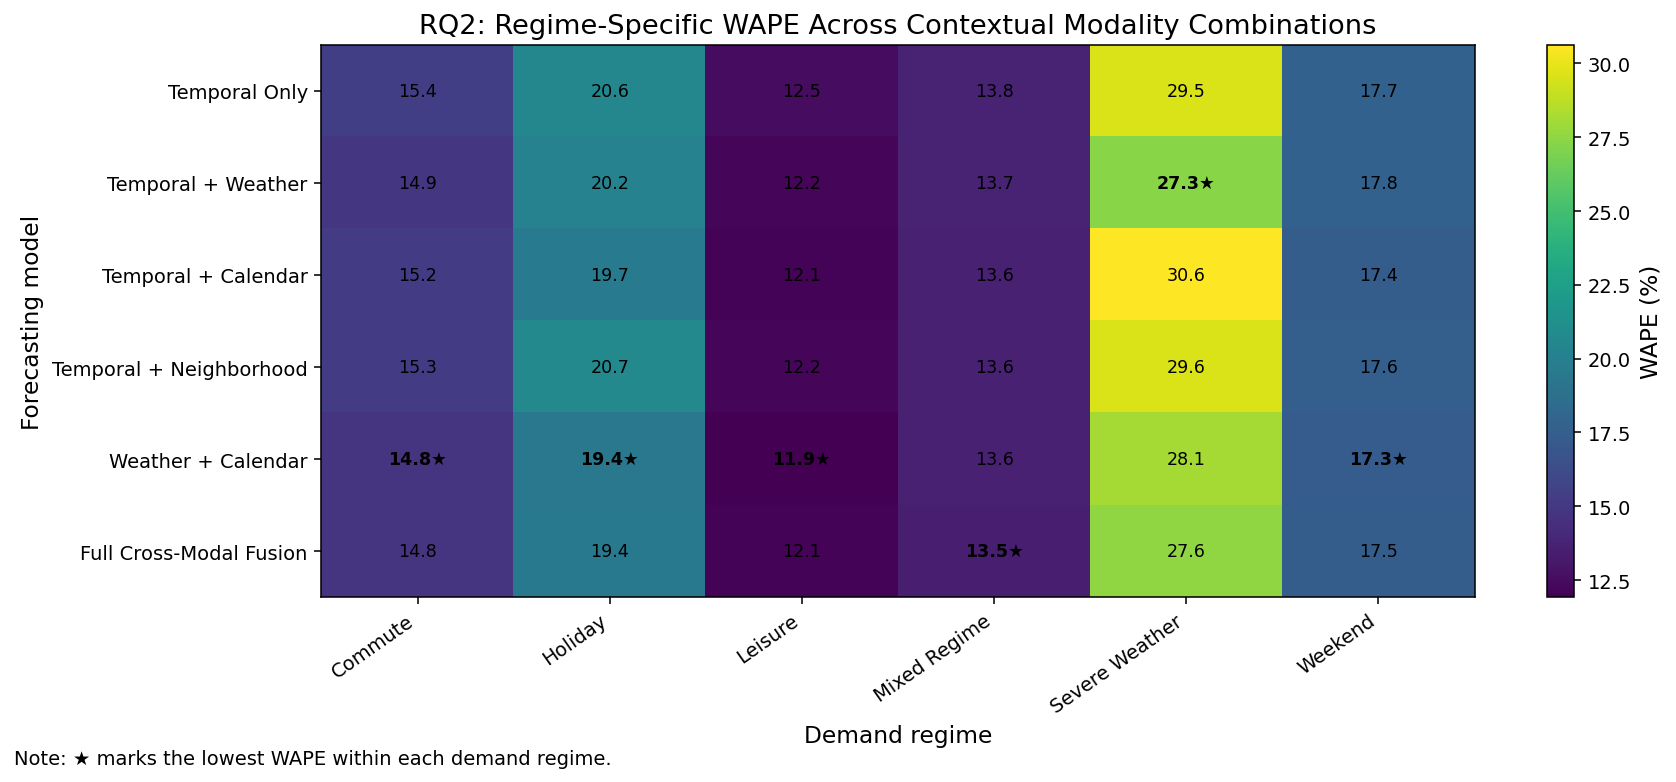

Saved figure: /kaggle/working/urban_demand_RQ2_outputs/figures_pdf/RQ2_Figure_2_modality_gain_by_regime_thesis_ready.pdf


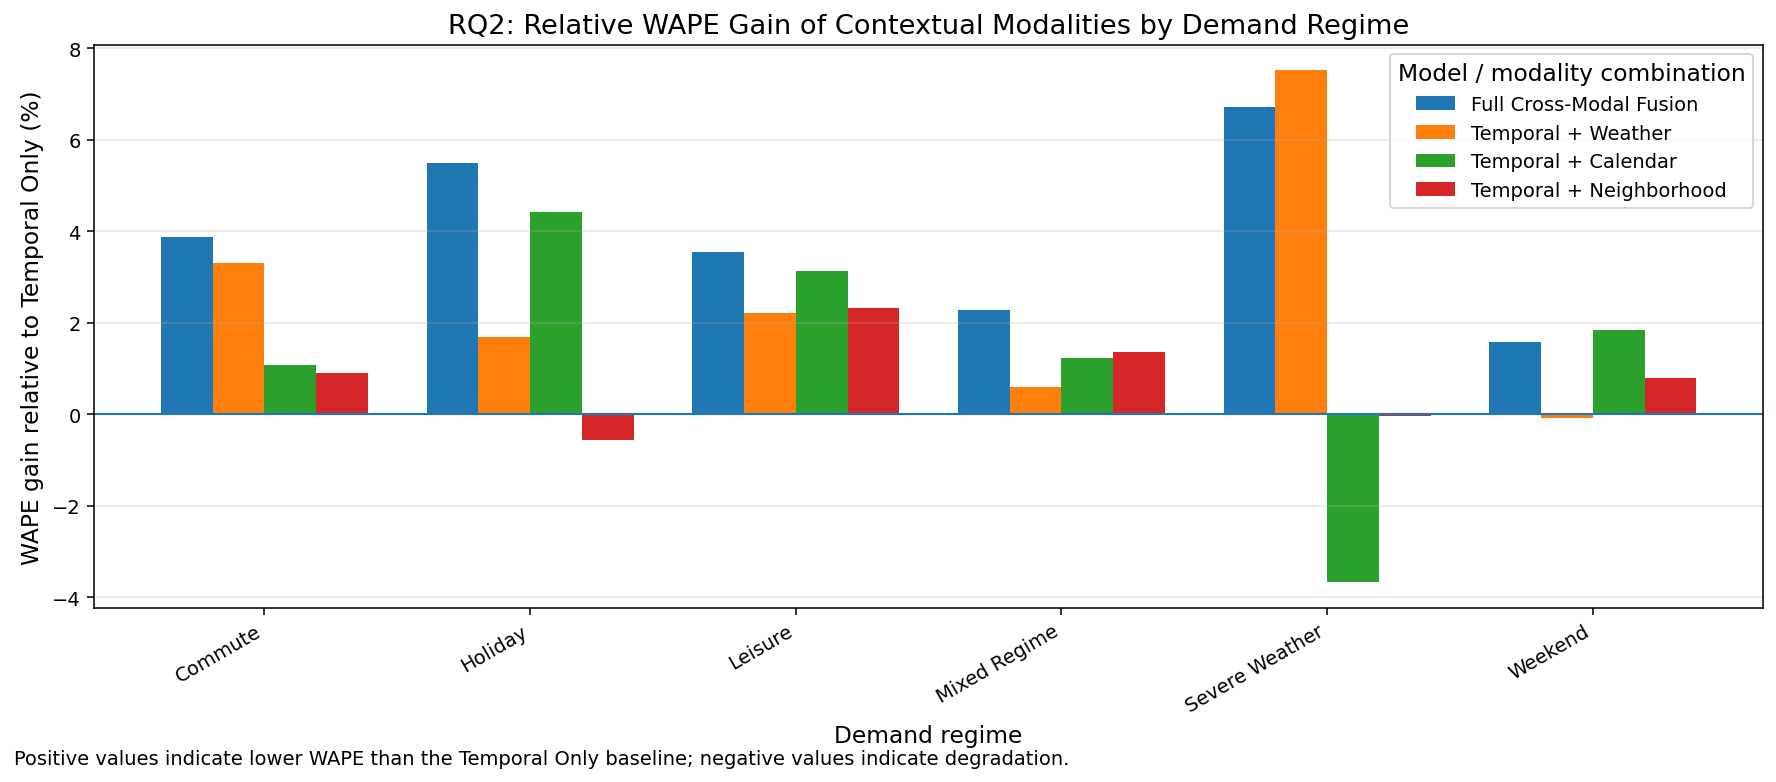

Saved figure: /kaggle/working/urban_demand_RQ2_outputs/figures_pdf/RQ2_Figure_3_dynamic_modality_importance_matrix_thesis_ready.pdf


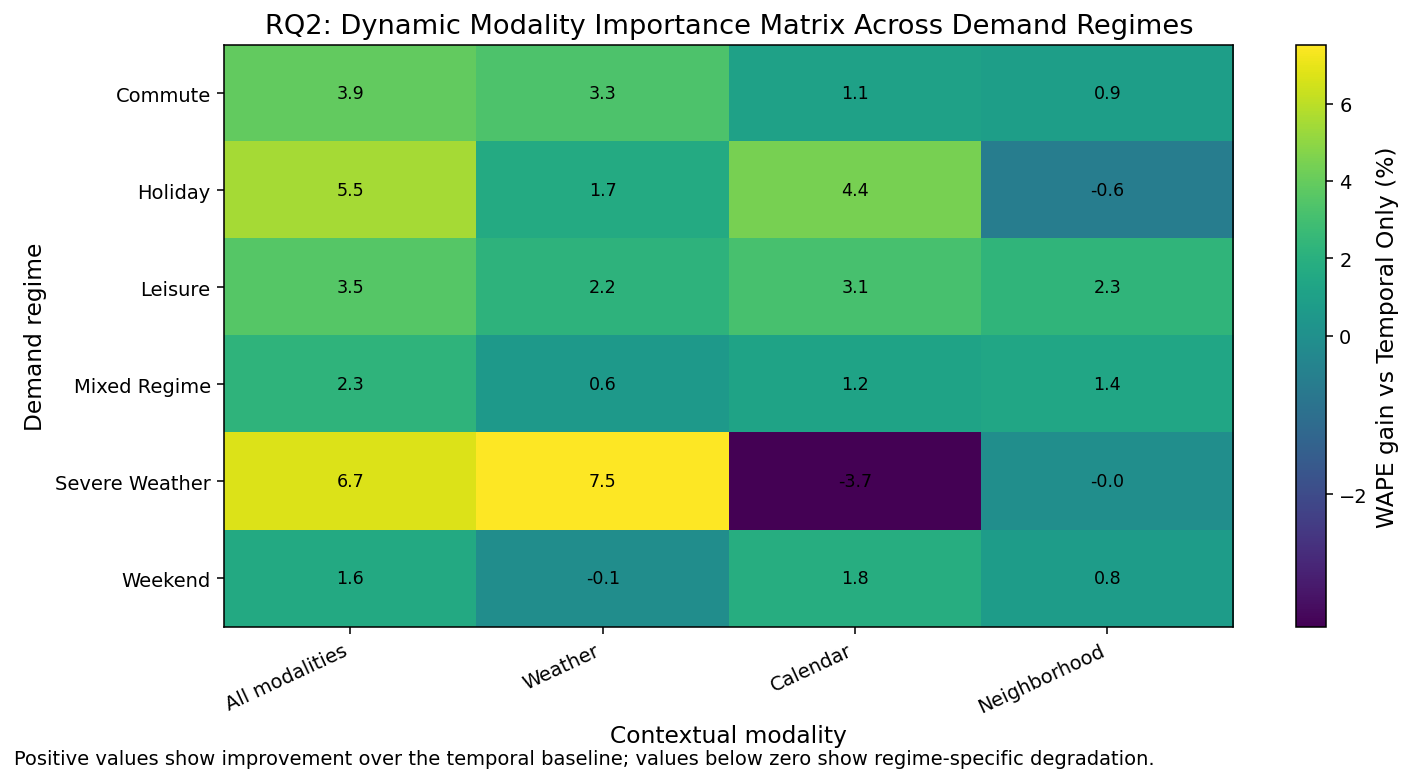

Saved figure: /kaggle/working/urban_demand_RQ2_outputs/figures_pdf/RQ2_Figure_4_proposed_error_by_regime_thesis_ready.pdf


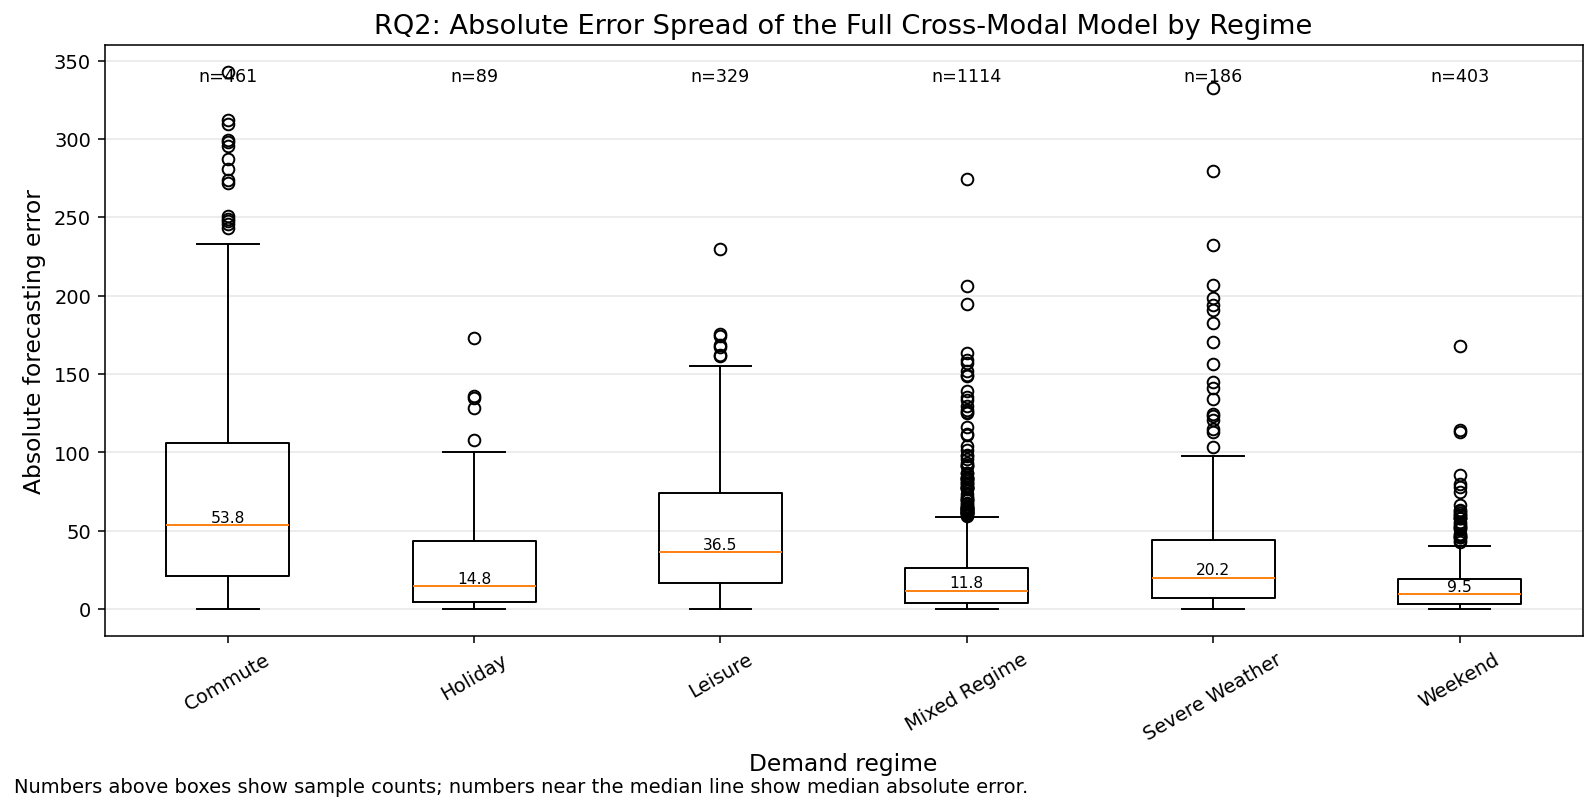


RQ2 thesis-safe conclusion: contextual modality usefulness is regime-dependent. The full cross-modal model should be described as competitive and stable overall, not as the best model in every regime.


In [5]:
# ============================================================
# RQ2: Regime-wise contribution of weather, calendar, and neighborhood modalities
# Thesis-ready version: careful interpretation, best-regime markers, and no overclaiming.
# Produces 4 PDF figures + 3 CSV tables.
# ============================================================
section('RQ2 — Regime-dependent contribution of contextual modalities')

variants = [
    'Temporal Only',
    'Temporal + Weather',
    'Temporal + Calendar',
    'Temporal + Neighborhood',
    'Weather + Calendar',
    'Full Cross-Modal Fusion'
]
regime_order = ['Commute', 'Holiday', 'Leisure', 'Mixed Regime', 'Severe Weather', 'Weekend']
regime_order = [r for r in regime_order if r in TEST['regime'].unique()]

perf, preds, models = evaluate_variants(variants=variants, model_name='rf')

# ------------------------------------------------------------
# Table 1: Regime-wise ablation performance
# ------------------------------------------------------------
rows = []
for reg in regime_order:
    mask = TEST['regime'].eq(reg).values
    for name, pred in preds.items():
        m = metrics(TEST.loc[mask, TARGET], pred[mask])
        rows.append({'Regime': reg, 'Model': name, 'N observations': int(mask.sum()), **m})

regime_perf = pd.DataFrame(rows)
# Mark best model per regime using WAPE, because RQ2 focuses on regime-wise forecasting contribution.
best_idx = regime_perf.groupby('Regime')['WAPE (%)'].idxmin()
regime_perf['Best in Regime by WAPE'] = False
regime_perf.loc[best_idx, 'Best in Regime by WAPE'] = True
regime_perf = regime_perf.sort_values(['Regime', 'WAPE (%)']).reset_index(drop=True)
save_table(regime_perf, 'RQ2_Table_1_regime_wise_ablation_results_thesis_ready')

# ------------------------------------------------------------
# Table 2: Modality gains relative to Temporal Only
# Positive gain = lower WAPE than Temporal Only; negative = worse than Temporal Only.
# ------------------------------------------------------------
base = regime_perf[regime_perf['Model'].eq('Temporal Only')][['Regime', 'WAPE (%)']].rename(
    columns={'WAPE (%)': 'Temporal Only WAPE (%)'}
)
gains = regime_perf.merge(base, on='Regime')
gains['WAPE Gain vs Temporal Only (%)'] = (
    (gains['Temporal Only WAPE (%)'] - gains['WAPE (%)']) / gains['Temporal Only WAPE (%)'] * 100
)
gains['Gain Interpretation'] = np.where(
    gains['WAPE Gain vs Temporal Only (%)'] > 0,
    'Improves over Temporal Only',
    np.where(gains['WAPE Gain vs Temporal Only (%)'] < 0, 'Worse than Temporal Only', 'No change')
)
gains = gains.sort_values(['Regime', 'WAPE Gain vs Temporal Only (%)'], ascending=[True, False]).reset_index(drop=True)
save_table(gains, 'RQ2_Table_2_modality_gain_by_regime_thesis_ready')

# ------------------------------------------------------------
# Table 3: Best model and thesis-safe interpretation for each regime
# ------------------------------------------------------------
best_regime = regime_perf.loc[best_idx].copy().sort_values('Regime').reset_index(drop=True)
interpretation_map = {
    'Temporal + Weather': 'Weather context is the dominant useful modality for this regime.',
    'Temporal + Calendar': 'Calendar/temporal context is the dominant useful modality for this regime.',
    'Temporal + Neighborhood': 'Neighborhood-context features are the dominant useful modality for this regime.',
    'Weather + Calendar': 'Combined weather and calendar signals provide the strongest regime-specific improvement.',
    'Full Cross-Modal Fusion': 'Full multimodal integration provides the strongest regime-specific improvement.',
    'Temporal Only': 'Historical and temporal demand patterns are sufficient or contextual features do not improve this regime.'
}
best_regime['Thesis-safe Interpretation'] = best_regime['Model'].map(interpretation_map)
save_table(best_regime, 'RQ2_Table_3_best_modality_combination_per_regime_thesis_ready')

# ------------------------------------------------------------
# Figure 1: Heatmap with best model per regime marked
# ------------------------------------------------------------
heat = regime_perf.pivot(index='Model', columns='Regime', values='WAPE (%)').reindex(index=variants, columns=regime_order)
fig, ax = plt.subplots(figsize=(12.8, 5.6))
im = ax.imshow(heat.values, aspect='auto')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=35, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel('Demand regime')
ax.set_ylabel('Forecasting model')
ax.set_title('RQ2: Regime-Specific WAPE Across Contextual Modality Combinations')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('WAPE (%)')

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if np.isfinite(val):
            is_best = val == np.nanmin(heat.iloc[:, j].values)
            label = f'{val:.1f}' + ('★' if is_best else '')
            ax.text(j, i, label, ha='center', va='center', fontsize=9, fontweight='bold' if is_best else 'normal')

# Add a short note directly on the figure so the thesis reader understands the star.
fig.text(0.01, 0.01, 'Note: ★ marks the lowest WAPE within each demand regime.', fontsize=10)
save_fig('RQ2_Figure_1_regime_wape_heatmap_thesis_ready')

# ------------------------------------------------------------
# Figure 2: Relative gain bar chart with zero reference line
# ------------------------------------------------------------
gain_models = ['Full Cross-Modal Fusion', 'Temporal + Weather', 'Temporal + Calendar', 'Temporal + Neighborhood']
gain_plot = gains[gains['Model'].isin(gain_models)].copy()
piv = gain_plot.pivot(index='Regime', columns='Model', values='WAPE Gain vs Temporal Only (%)').reindex(index=regime_order, columns=gain_models)
ax = piv.plot(kind='bar', figsize=(12.8, 5.6), width=0.78)
ax.axhline(0, linewidth=1.1)
ax.set_title('RQ2: Relative WAPE Gain of Contextual Modalities by Demand Regime')
ax.set_xlabel('Demand regime')
ax.set_ylabel('WAPE gain relative to Temporal Only (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Model / modality combination', loc='best')
fig = ax.get_figure()
fig.text(0.01, 0.01, 'Positive values indicate lower WAPE than the Temporal Only baseline; negative values indicate degradation.', fontsize=10)
save_fig('RQ2_Figure_2_modality_gain_by_regime_thesis_ready')

# ------------------------------------------------------------
# Figure 3: Dynamic modality importance matrix using gains
# ------------------------------------------------------------
from matplotlib.colors import TwoSlopeNorm
modality_map = {
    'Full Cross-Modal Fusion': 'All modalities',
    'Temporal + Weather': 'Weather',
    'Temporal + Calendar': 'Calendar',
    'Temporal + Neighborhood': 'Neighborhood'
}
dom = gains[gains['Model'].isin(modality_map.keys())].copy()
dom['Modality'] = dom['Model'].map(modality_map)
modality_order = ['All modalities', 'Weather', 'Calendar', 'Neighborhood']
dom_piv = dom.pivot(index='Regime', columns='Modality', values='WAPE Gain vs Temporal Only (%)').reindex(index=regime_order, columns=modality_order)

fig, ax = plt.subplots(figsize=(10.8, 5.6))
vmin = float(np.nanmin(dom_piv.values))
vmax = float(np.nanmax(dom_piv.values))
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
im = ax.imshow(dom_piv.values, aspect='auto', norm=norm)
ax.set_xticks(range(len(dom_piv.columns)))
ax.set_xticklabels(dom_piv.columns, rotation=25, ha='right')
ax.set_yticks(range(len(dom_piv.index)))
ax.set_yticklabels(dom_piv.index)
ax.set_xlabel('Contextual modality')
ax.set_ylabel('Demand regime')
ax.set_title('RQ2: Dynamic Modality Importance Matrix Across Demand Regimes')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('WAPE gain vs Temporal Only (%)')
for i in range(dom_piv.shape[0]):
    for j in range(dom_piv.shape[1]):
        val = dom_piv.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9)
fig.text(0.01, 0.01, 'Positive values show improvement over the temporal baseline; values below zero show regime-specific degradation.', fontsize=10)
save_fig('RQ2_Figure_3_dynamic_modality_importance_matrix_thesis_ready')

# ------------------------------------------------------------
# Figure 4: Proposed model error spread across regimes with sample counts
# ------------------------------------------------------------
prop_err = pd.DataFrame({
    'Regime': TEST['regime'].values,
    'Absolute Error': np.abs(TEST[TARGET].values - preds['Full Cross-Modal Fusion'])
})
plot_data = [prop_err.loc[prop_err['Regime'].eq(reg), 'Absolute Error'].values for reg in regime_order]
fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.boxplot(plot_data, labels=regime_order, showfliers=True)
ax.set_title('RQ2: Absolute Error Spread of the Full Cross-Modal Model by Regime')
ax.set_xlabel('Demand regime')
ax.set_ylabel('Absolute forecasting error')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for i, reg in enumerate(regime_order, start=1):
    n = len(prop_err.loc[prop_err['Regime'].eq(reg)])
    median = prop_err.loc[prop_err['Regime'].eq(reg), 'Absolute Error'].median()
    ax.text(i, ax.get_ylim()[1]*0.96, f'n={n}', ha='center', va='top', fontsize=9)
    ax.text(i, median, f'{median:.1f}', ha='center', va='bottom', fontsize=8)
fig.text(0.01, 0.01, 'Numbers above boxes show sample counts; numbers near the median line show median absolute error.', fontsize=10)
save_fig('RQ2_Figure_4_proposed_error_by_regime_thesis_ready')

print('\nRQ2 thesis-safe conclusion: contextual modality usefulness is regime-dependent. The full cross-modal model should be described as competitive and stable overall, not as the best model in every regime.')


In [6]:

# ============================================================
# Final export: ZIP all tables and figures from this RQ
# ============================================================
zip_outputs()


Final ZIP created: /kaggle/working/urban_demand_RQ2_outputs.zip


PosixPath('/kaggle/working/urban_demand_RQ2_outputs.zip')